In [2]:
pip install pandas numpy scikit-learn xgboost imblearn matplotlib tensorflow keras

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl.metadata (19 kB)
  Using cached numpy-2.2.6-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached scikit_learn-1.7.2-cp310-cp310-win_amd64.whl.metadata (11 kB)
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached matplotlib-3.10.8-cp310-cp310-win_amd64.whl.metadata (52 kB)
  Using cached keras-3.12.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached pytz-2026.1.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached scipy-1.15.3-cp310-cp310-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached contourpy-1.3.2-cp310-cp310-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-win_amd64.whl.metadata (119 kB)
  Using ca


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from imblearn.combine import SMOTETomek
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import ADASYN
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers
import pickle

In [4]:
data = pd.read_csv('../data/fsml_data.csv')
data.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [5]:
data.tail()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
12311,16:15:00,Wednesday,31-50,Male,NaN,Employee,2-5yr,Lorry (11?40Q),Owner,NaN,...,Going straight,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12312,18:00:00,Sunday,Unknown,Male,Elementary school,Employee,5-10yr,Automobile,Owner,NaN,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,No distancing,Slight Injury
12313,13:55:00,Sunday,Over 51,Male,Junior high school,Employee,5-10yr,Bajaj,Owner,2-5yrs,...,Other,Driver or rider,Male,31-50,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Serious Injury
12314,13:55:00,Sunday,18-30,Female,Junior high school,Employee,Above 10yr,Lorry (41?100Q),Owner,2-5yrs,...,Other,na,na,na,na,Driver,Normal,Not a Pedestrian,Driving under the influence of drugs,Slight Injury
12315,13:55:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Other,Owner,2-5yrs,...,Stopping,Pedestrian,Female,5,3,Driver,Normal,Crossing from nearside - masked by parked or s...,Changing lane to the right,Slight Injury


Feature Engineering

In [6]:
data.drop(columns=['Time'], inplace=True)


In [7]:
data.drop(columns=['Day_of_week','Owner_of_vehicle','Service_year_of_vehicle', 'Defect_of_vehicle','Road_allignment','Number_of_vehicles_involved', 'Casualty_class', 'Sex_of_casualty', 'Age_band_of_casualty', 'Casualty_severity', 'Work_of_casuality', 'Fitness_of_casuality'], axis=1, inplace = True)

In [8]:
data.dropna(inplace=True)

In [10]:
label = LabelEncoder()
data['Accident_severity'] = label.fit_transform(data['Accident_severity'])
list_col = data.columns.to_list()
for i in list_col:
    data[i] = label.fit_transform(data[i])

In [11]:
data.head()

,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Area_accident_occured,Lanes_or_Medians,Types_of_Junction,Road_surface_type,Road_surface_conditions,Light_conditions,Weather_conditions,Type_of_collision,Number_of_casualties,Vehicle_movement,Pedestrian_movement,Cause_of_accident,Accident_severity
1,1,1,4,0,3,11,6,4,1,0,0,3,2,8,1,2,5,16,2
2,0,1,4,0,0,5,1,6,1,0,0,3,2,2,1,2,5,0,1
3,0,1,4,0,2,11,6,6,7,2,0,0,2,8,1,2,5,1,2
7,0,1,4,0,1,0,9,6,7,0,0,3,2,8,0,10,5,12,2
8,0,1,4,0,3,5,4,6,7,2,0,3,2,3,0,2,0,1,2


Plots

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_11648\1899746062.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


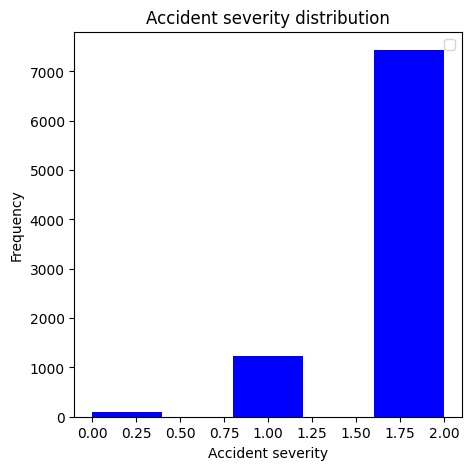

In [14]:
plt.figure(figsize = (5,5))
plt.hist(data['Accident_severity'], color='blue', bins=5)
plt.title('Accident severity distribution')
plt.xlabel('Accident severity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

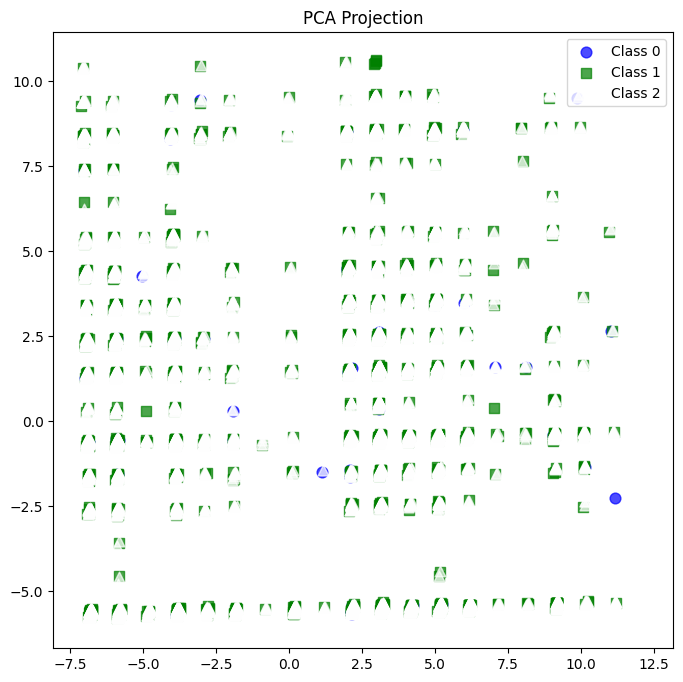

In [18]:
pca_obj = PCA(n_components=2)
df = pca_obj.fit_transform(data)
y = data['Accident_severity']

def plot_2d(X_red, y, title):
    plt.figure(figsize=(8,8))

    colors = {
        0: 'blue',
        1: 'green',
        2: 'white'
    }

    markers = {
        0: 'o',   # circle
        1: 's',   # square
        2: '^'    # triangle
    }

    for cls in sorted(set(y)):
        plt.scatter(
            X_red[y == cls, 0],
            X_red[y == cls, 1],
            label=f"Class {cls}",
            alpha=0.7,
            color=colors.get(cls, 'black'),
            marker=markers.get(cls, 'o'),
            s=60   # size of points
        )

    plt.legend()
    plt.title(title)
    plt.show()

plot_2d(df, y, "PCA Projection")


In [19]:
print(np.unique(y))


[0 1 2]


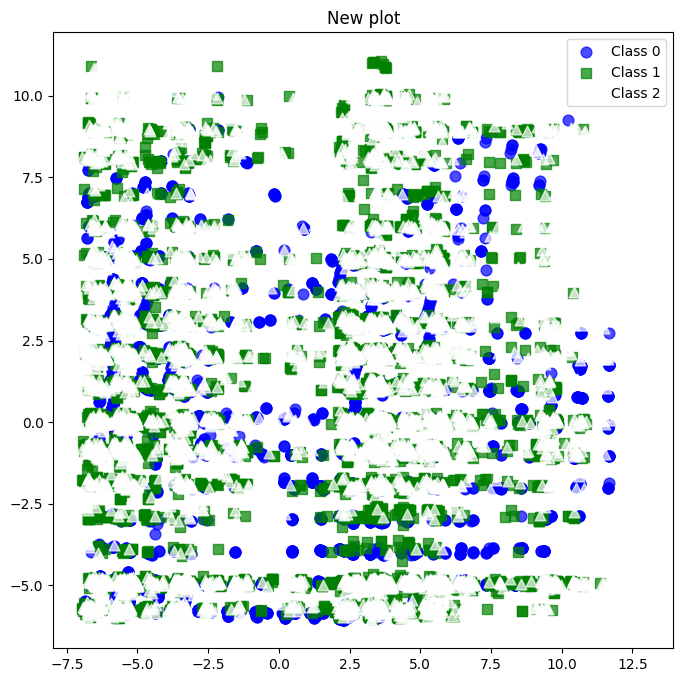

In [20]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
dff = data.drop(columns=['Accident_severity'])
x_train, x_test, y_train, y_test = train_test_split(dff,y, test_size=0.2, random_state=42)
sm = SMOTE(random_state=42)
x_resample, y_resample = sm.fit_resample(x_train, y_train)
da = pca_obj.fit_transform(x_resample)
plot_2d(da, y_resample, "New plot")

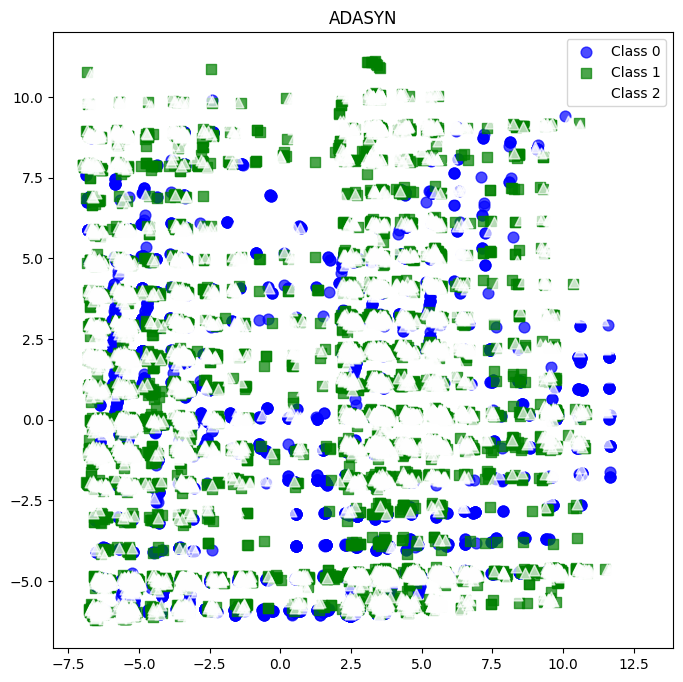

In [21]:
from imblearn.over_sampling import ADASYN
ada = ADASYN(random_state=42)
x_resample_ada, y_resample_ada = ada.fit_resample(x_train, y_train)
data_ada = pca_obj.fit_transform(x_resample_ada)
plot_2d(data_ada, y_resample_ada, "ADASYN")

In [22]:
dff = data.drop(columns=['Accident_severity'])
x_train, x_test, y_train, y_test = train_test_split(dff,y, test_size=0.4, random_state=42)
sm = SMOTETomek(random_state=42)
x_resample, y_resample = sm.fit_resample(x_train, y_train)

In [33]:
tree = DecisionTreeClassifier(random_state=42, max_depth=10)
tree.fit(x_resample_ada, y_resample_ada)
pickle.dump(tree, open('model_v1.pkl','wb'))
y_pred = tree.predict(x_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
# f1 = f1_score(y_test, y_pred)
print(classification_report(y_test, y_pred))
ensemble = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
ensemble.fit(x_resample_ada, y_resample_ada)
y_pred = ensemble.predict(x_test)
print(classification_report(y_test, y_pred))
# ensemble.save('model_v2.pkl')
pickle.dump(ensemble, open('model_v2.pkl','wb'))

              precision    recall  f1-score   support

           0       0.09      0.51      0.15        47
           1       0.20      0.48      0.28       485
           2       0.89      0.61      0.72      2973

    accuracy                           0.59      3505
   macro avg       0.39      0.53      0.38      3505
weighted avg       0.78      0.59      0.65      3505

              precision    recall  f1-score   support

           0       0.72      0.62      0.67        47
           1       0.62      0.55      0.58       485
           2       0.92      0.94      0.93      2973

    accuracy                           0.88      3505
   macro avg       0.75      0.70      0.73      3505
weighted avg       0.88      0.88      0.88      3505

